In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.5.3


In [2]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 478.2 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.3 MB 478.2 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.3 MB 485.5 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.3 MB 485.5 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.3 MB 485.5 kB/s eta 0:00:18
   ---- ----------------------------------- 1.0/9.3 MB 490.4 kB/s eta 0:00:17
   ---- ----------------------------------- 1.0/9.3 MB 490.4 kB/s eta 0:00:17
   ----- -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

TensorFlow: 2.21.0
NumPy: 2.5.3
Matplotlib: 3.11.2


## 1. Dataset

The dataset contains images of fabrics belonging to different defect categories.
The images will be preprocessed and divided into training, validation, and testing sets for deep learning-based defect classification.

In [2]:
%pip install kagglehub


   ---------------------------------------- 0/3 [pyyaml]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   -------------------------- ------------- 2/3 [kagglehub]
   ---------------------------------------- 3/3 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "ziya07/multi-class-fabric-defect-detection-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

C:\Users\shrij\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to:
C:\Users\shrij\.cache\kagglehub\datasets\ziya07\multi-class-fabric-defect-detection-dataset\versions\3


In [5]:
import os

print("Dataset location:")
print(dataset_path)

print("\nFolders and files:")

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)
    if os.path.isdir(full_path):
        print("📁", item)
    else:
        print("📄", item)

Dataset location:
C:\Users\shrij\.cache\kagglehub\datasets\ziya07\multi-class-fabric-defect-detection-dataset\versions\3

Folders and files:
📁 Dataset


In [6]:
import os

dataset_folder = os.path.join(dataset_path, "Dataset")

print("Dataset folder:")
print(dataset_folder)

print("\nClasses:")

for item in sorted(os.listdir(dataset_folder)):
    full_path = os.path.join(dataset_folder, item)
    if os.path.isdir(full_path):
        print("📁", item)

Dataset folder:
C:\Users\shrij\.cache\kagglehub\datasets\ziya07\multi-class-fabric-defect-detection-dataset\versions\3\Dataset

Classes:
📁 Broken stitch
📁 Needle mark
📁 Pinched fabric
📁 Vertical
📁 defect free
📁 hole
📁 horizontal
📁 lines
📁 stain


In [7]:
import os

class_counts = {}

for class_name in sorted(os.listdir(dataset_folder)):
    class_path = os.path.join(dataset_folder, class_name)
    
    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])
        class_counts[class_name] = image_count

print("Image count per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal images:", sum(class_counts.values()))

Image count per class:

Broken stitch: 112
Needle mark: 108
Pinched fabric: 108
Vertical: 101
defect free: 1666
hole: 281
horizontal: 136
lines: 157
stain: 398

Total images: 3067


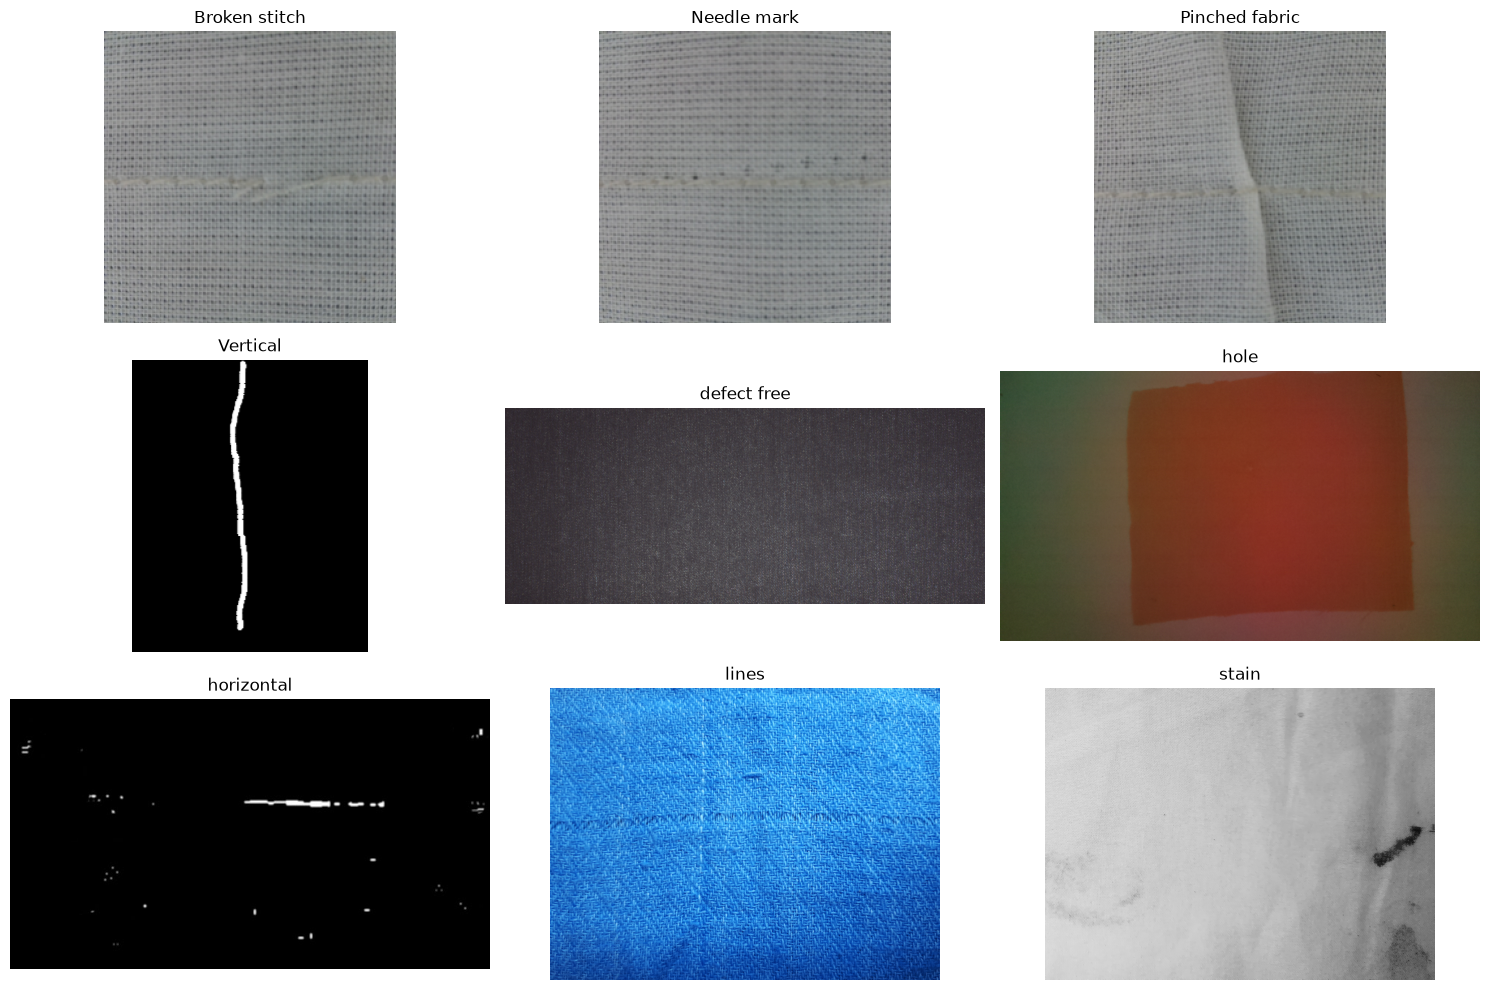

In [8]:
import matplotlib.pyplot as plt
import os
import random

classes = sorted(class_counts.keys())

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_folder, class_name)
    
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    
    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)
    
    img = plt.imread(image_path)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
from PIL import Image
import os

image_sizes = {}

for class_name in classes:
    class_path = os.path.join(dataset_folder, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            image_path = os.path.join(class_path, file)

            with Image.open(image_path) as img:
                size = img.size

            image_sizes[size] = image_sizes.get(size, 0) + 1

print("Different image sizes found:\n")

for size, count in sorted(image_sizes.items(), key=lambda x: x[1], reverse=True):
    print(f"{size}: {count} images")

Different image sizes found:

(2446, 1000): 1457 images
(640, 360): 412 images
(224, 224): 328 images
(1984, 1488): 305 images
(1280, 720): 232 images
(1488, 1984): 161 images
(4096, 256): 141 images
(4608, 3456): 22 images
(219, 264): 2 images
(221, 264): 2 images
(233, 288): 2 images
(201, 274): 2 images
(220, 270): 1 images


In [10]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_folder,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_folder,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Split the remaining 30% into validation and test sets
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
test_batches = temp_batches // 2

test_ds = temp_ds.take(test_batches)
val_ds = temp_ds.skip(test_batches)

class_names = train_ds.class_names

print("Classes:")
print(class_names)

print("\nTraining batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 3067 files belonging to 9 classes.
Using 2147 files for training.
Found 3067 files belonging to 9 classes.
Using 920 files for validation.
Classes:
['Broken stitch', 'Needle mark', 'Pinched fabric', 'Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']

Training batches: 68
Validation batches: 15
Testing batches: 14


In [11]:
from collections import Counter

def count_labels(dataset):
    counts = Counter()
    
    for images, labels in dataset:
        counts.update(labels.numpy().tolist())
    
    return counts


train_counts = count_labels(train_ds)
val_counts = count_labels(val_ds)
test_counts = count_labels(test_ds)

print("TRAINING SET")
for i, name in enumerate(class_names):
    print(f"{name}: {train_counts[i]}")

print("\nVALIDATION SET")
for i, name in enumerate(class_names):
    print(f"{name}: {val_counts[i]}")

print("\nTEST SET")
for i, name in enumerate(class_names):
    print(f"{name}: {test_counts[i]}")

TRAINING SET
Broken stitch: 75
Needle mark: 76
Pinched fabric: 81
Vertical: 71
defect free: 1161
hole: 200
horizontal: 97
lines: 104
stain: 282

VALIDATION SET
Broken stitch: 14
Needle mark: 21
Pinched fabric: 9
Vertical: 17
defect free: 270
hole: 39
horizontal: 17
lines: 23
stain: 62

TEST SET
Broken stitch: 21
Needle mark: 14
Pinched fabric: 16
Vertical: 14
defect free: 239
hole: 46
horizontal: 20
lines: 29
stain: 49


In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get all training labels
train_labels = []

for images, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=train_labels
)

class_weights = {
    i: float(weights[i])
    for i in range(len(class_names))
}

print("Class weights:\n")

for i, name in enumerate(class_names):
    print(f"{name}: {class_weights[i]:.3f}")

Class weights:

Broken stitch: 3.181
Needle mark: 3.139
Pinched fabric: 2.945
Vertical: 3.360
defect free: 0.205
hole: 1.193
horizontal: 2.459
lines: 2.294
stain: 0.846


In [12]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
from tensorflow.keras import layers, models

IMG_SIZE = 128
NUM_CLASSES = len(class_names)

cnn_model = models.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,801 (12.61 MB)

 Trainable params: 3,305,801 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10


C:\Users\shrij\miniconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 661ms/step - accuracy: 0.2878 - loss: 1.7713 - val_accuracy: 0.6335 - val_loss: 1.3007
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 78s 602ms/step - accuracy: 0.5757 - loss: 1.3583 - val_accuracy: 0.6250 - val_loss: 1.2203
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 82s 598ms/step - accuracy: 0.6847 - loss: 1.1713 - val_accuracy: 0.7839 - val_loss: 0.9601
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 600ms/step - accuracy: 0.7406 - loss: 1.0062 - val_accuracy: 0.7839 - val_loss: 0.6652
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 85s 633ms/step - accuracy: 0.7629 - loss: 0.9547 - val_accuracy: 0.7373 - val_loss: 0.9174
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 690ms/step - accuracy: 0.7839 - loss: 0.8739 - val_accuracy: 0.7542 - val_loss: 0.5994
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 44s 640ms/step - accuracy: 0.7885 - loss: 0.8041 - val_accuracy: 0.5233 - val_loss: 1.0739
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 84s 656ms/step - accuracy: 0.7522 - loss: 0.8499 - val_accuracy: 0.697

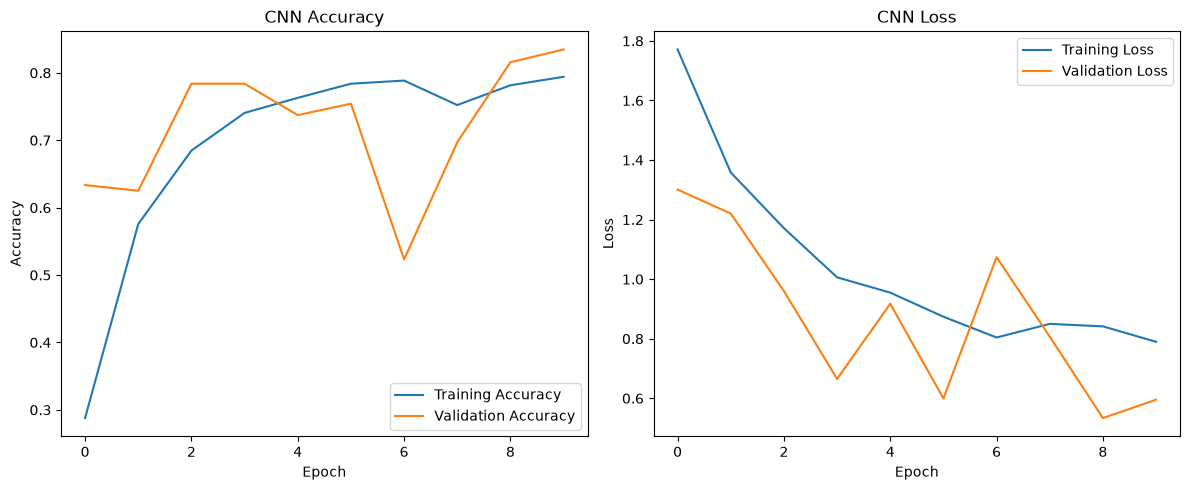

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Evaluate CNN on the test set

test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("CNN TEST RESULTS")
print("----------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 279ms/step - accuracy: 0.7790 - loss: 0.6360
CNN TEST RESULTS
----------------
Test Loss     : 0.6360
Test Accuracy : 0.7790
Test Accuracy : 77.90%


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print("CNN CLASSIFICATION REPORT")
print("==========================")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

CNN CLASSIFICATION REPORT
                precision    recall  f1-score   support

 Broken stitch     0.0000    0.0000    0.0000        23
   Needle mark     0.1613    1.0000    0.2778        10
Pinched fabric     0.0000    0.0000    0.0000        13
      Vertical     0.9000    0.5625    0.6923        16
   defect free     1.0000    0.8636    0.9268       242
          hole     0.8378    0.6889    0.7561        45
    horizontal     0.6471    0.8148    0.7213        27
         lines     0.8065    0.9259    0.8621        27
         stain     0.6935    0.9556    0.8037        45

      accuracy                         0.7790       448
     macro avg     0.5607    0.6457    0.5600       448
  weighted avg     0.8173    0.7790    0.7837       448



C:\Users\shrij\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shrij\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shrij\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


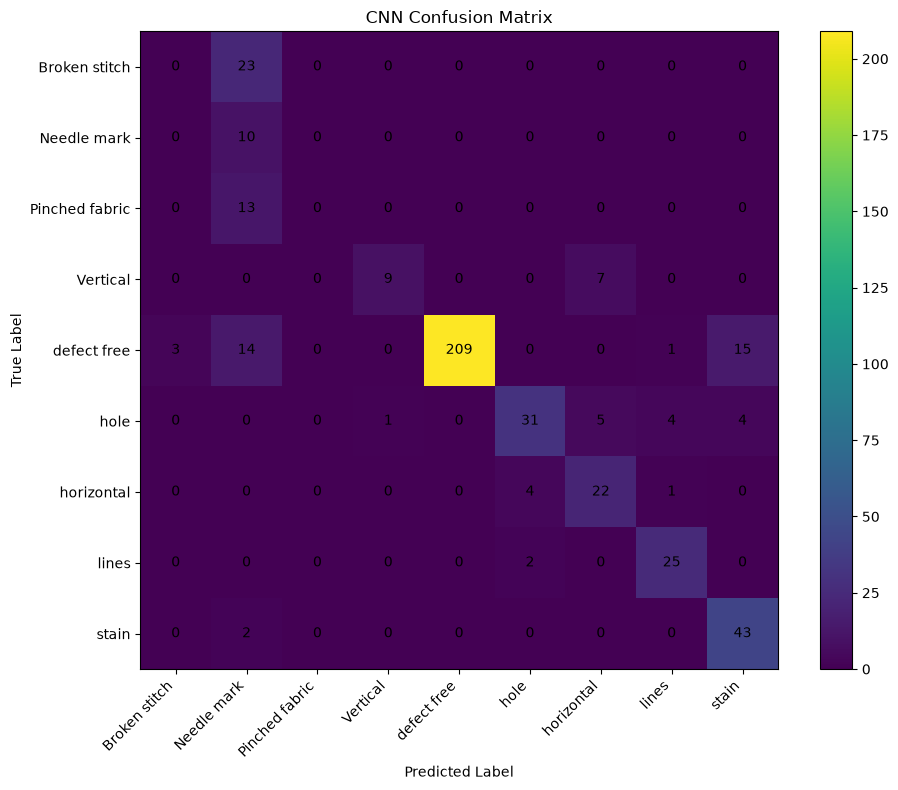

In [20]:
# CNN Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title("CNN Confusion Matrix")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Display values inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

In [21]:
# MobileNetV2 Transfer Learning Model

import tensorflow as tf

IMG_SIZE = 128

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained layers
base_model.trainable = False

mobilenet_model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 21s 2us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │          11,529 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# Prepare datasets for MobileNetV2

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_dataset(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

mobilenet_train_ds = train_ds.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)

mobilenet_val_ds = val_ds.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)

mobilenet_test_ds = test_ds.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)

mobilenet_train_ds = mobilenet_train_ds.prefetch(tf.data.AUTOTUNE)
mobilenet_val_ds = mobilenet_val_ds.prefetch(tf.data.AUTOTUNE)
mobilenet_test_ds = mobilenet_test_ds.prefetch(tf.data.AUTOTUNE)

print("MobileNetV2 datasets prepared successfully.")

MobileNetV2 datasets prepared successfully.


In [23]:
# Train MobileNetV2

mobilenet_history = mobilenet_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10


C:\Users\shrij\miniconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 584ms/step - accuracy: 0.6833 - loss: 1.1647 - val_accuracy: 0.8792 - val_loss: 0.3893
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 574ms/step - accuracy: 0.8873 - loss: 0.4571 - val_accuracy: 0.8919 - val_loss: 0.3028
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 552ms/step - accuracy: 0.9008 - loss: 0.3760 - val_accuracy: 0.9089 - val_loss: 0.2636
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 575ms/step - accuracy: 0.9096 - loss: 0.3356 - val_accuracy: 0.9195 - val_loss: 0.2344
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 35s 491ms/step - accuracy: 0.9306 - loss: 0.2790 - val_accuracy: 0.9428 - val_loss: 0.1953
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 492ms/step - accuracy: 0.9376 - loss: 0.2301 - val_accuracy: 0.9237 - val_loss: 0.2374
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 47s 581ms/step - accuracy: 0.9390 - loss: 0.2075 - val_accuracy: 0.9322 - val_loss: 0.2023
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 556ms/step - accuracy: 0.9408 - loss: 0.1846 - val_accuracy: 0.934

In [25]:
# MobileNetV2 Test Evaluation

test_loss, test_accuracy = mobilenet_model.evaluate(
    mobilenet_test_ds,
    verbose=1
)

print("\nMOBILENETV2 TEST RESULTS")
print("------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 433ms/step - accuracy: 0.9196 - loss: 0.2005

MOBILENETV2 TEST RESULTS
------------------------
Test Loss     : 0.2005
Test Accuracy : 0.9196
Test Accuracy : 91.96%


In [26]:
from sklearn.metrics import classification_report
import numpy as np

y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in mobilenet_test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)
    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(np.argmax(predictions, axis=1))

y_true_mobilenet = np.array(y_true_mobilenet)
y_pred_mobilenet = np.array(y_pred_mobilenet)

print("MOBILENETV2 CLASSIFICATION REPORT")
print("=================================")

print(classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=class_names,
    digits=4
))

MOBILENETV2 CLASSIFICATION REPORT
                precision    recall  f1-score   support

 Broken stitch     0.8929    1.0000    0.9434        25
   Needle mark     1.0000    0.9286    0.9630        14
Pinched fabric     1.0000    0.8889    0.9412        18
      Vertical     0.7778    0.8235    0.8000        17
   defect free     0.9915    0.9588    0.9749       243
          hole     0.8333    0.7353    0.7812        34
    horizontal     0.7500    0.8333    0.7895        18
         lines     0.8966    0.8966    0.8966        29
         stain     0.8305    0.9800    0.8991        50

      accuracy                         0.9286       448
     macro avg     0.8858    0.8939    0.8876       448
  weighted avg     0.9327    0.9286    0.9291       448



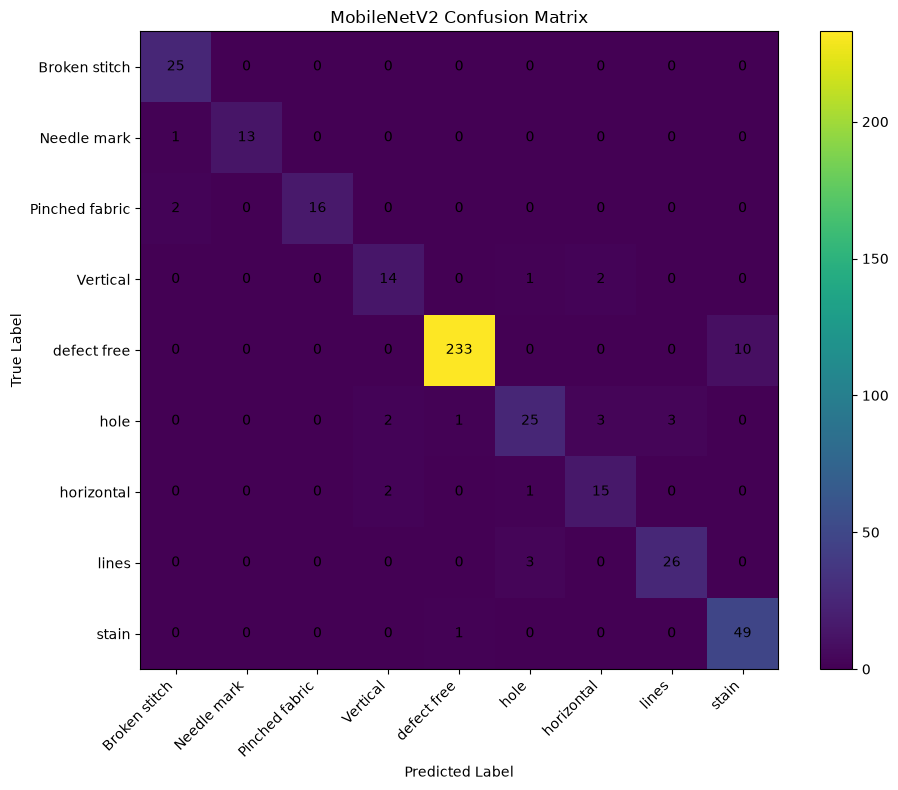

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet
)

plt.figure(figsize=(10, 8))

plt.imshow(cm_mobilenet, interpolation='nearest')
plt.title("MobileNetV2 Confusion Matrix")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm_mobilenet[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [29]:
comparison = {
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy (%)": [77.90, 91.96],
    "Macro F1": [0.5600, 0.8876],
    "Weighted F1": [0.7837, 0.9291]
}

for i in range(2):
    print(f"\nModel: {comparison['Model'][i]}")
    print(f"Test Accuracy: {comparison['Test Accuracy (%)'][i]:.2f}%")
    print(f"Macro F1: {comparison['Macro F1'][i]:.4f}")
    print(f"Weighted F1: {comparison['Weighted F1'][i]:.4f}")


Model: Custom CNN
Test Accuracy: 77.90%
Macro F1: 0.5600
Weighted F1: 0.7837

Model: MobileNetV2
Test Accuracy: 91.96%
Macro F1: 0.8876
Weighted F1: 0.9291


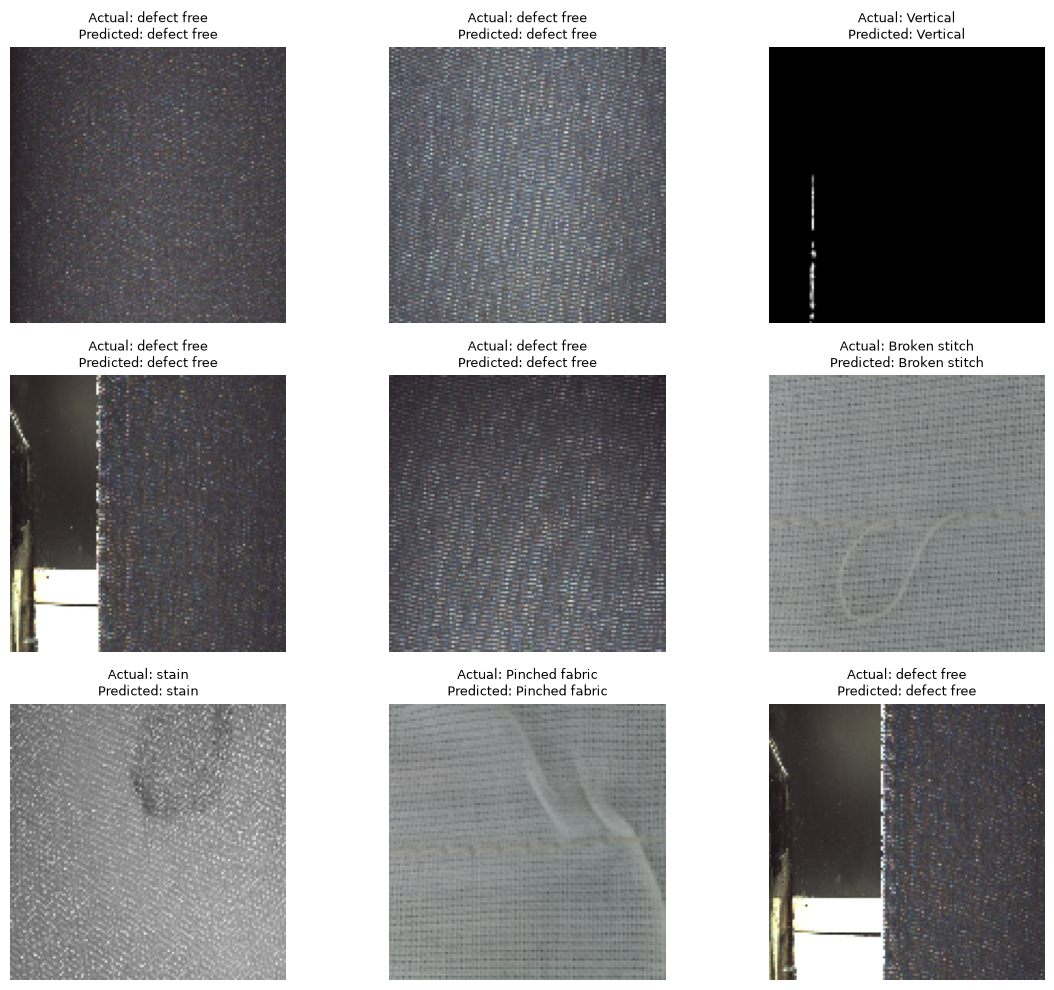

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))

for images, labels in mobilenet_test_ds.take(1):
    predictions = mobilenet_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        # Convert image from [-1, 1] back to [0, 1]
        image = images[i].numpy()
        image = (image + 1.0) / 2.0
        image = np.clip(image, 0, 1)

        plt.imshow(image)

        actual = class_names[labels[i].numpy()]
        predicted = class_names[predicted_labels[i]]

        if actual == predicted:
            title = f"Actual: {actual}\nPredicted: {predicted}"
        else:
            title = f"Actual: {actual}\nPredicted: {predicted}"

        plt.title(title, fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
mobilenet_model.save("fabric_defect_mobilenetv2.keras")

print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def predict_fabric_defect(image_path):
    # Load image
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(128, 128)
    )

    # Convert to array
    image_array = tf.keras.utils.img_to_array(image)

    # MobileNetV2 preprocessing
    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    prediction = mobilenet_model.predict(image_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("Predicted Defect :", predicted_class)
    print(f"Confidence       : {confidence:.2f}%")

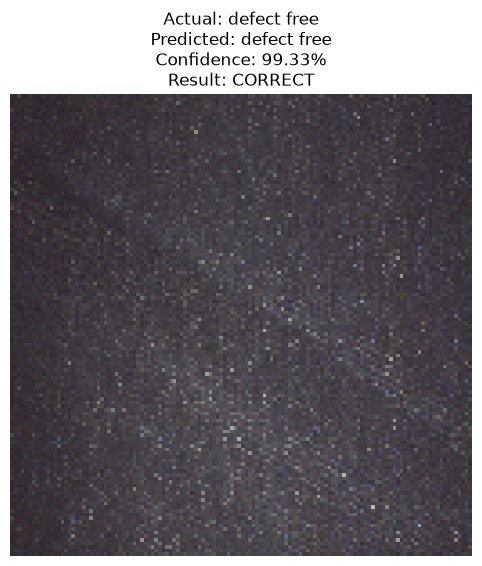

Actual Class    : defect free
Predicted Class : defect free
Confidence      : 99.33%
Result          : CORRECT


In [38]:
# Final Sample Prediction

image_path = random.choice(image_files)

actual_class = os.path.basename(os.path.dirname(image_path))

image = tf.keras.utils.load_img(
    image_path,
    target_size=(128, 128)
)

image_array = tf.keras.utils.img_to_array(image)

processed_image = tf.keras.applications.mobilenet_v2.preprocess_input(
    image_array
)

processed_image = np.expand_dims(processed_image, axis=0)

prediction = mobilenet_model.predict(processed_image, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

result = "CORRECT" if actual_class == predicted_class else "INCORRECT"

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"Result: {result}"
)
plt.axis("off")
plt.show()

print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")
print("Result          :", result)

## Final Model Performance

Two deep learning approaches were implemented and evaluated for fabric defect classification.

### Custom CNN
- Test Accuracy: 77.90%
- Macro F1-score: 0.5600
- Weighted F1-score: 0.7837

### MobileNetV2
- Test Accuracy: 91.96%
- Macro F1-score: 0.8876
- Weighted F1-score: 0.9291

### Best Model

MobileNetV2 achieved the best overall performance. Compared with the custom CNN, it improved test accuracy by approximately 14 percentage points and produced substantially better macro F1-score.

The improvement demonstrates the effectiveness of transfer learning for fabric defect classification, particularly when working with a relatively small and imbalanced image dataset.

## Challenges

1. **Class Imbalance**
   - The dataset contains significantly more defect-free images than some defect categories.
   - Class weights were therefore used during training.

2. **Different Image Dimensions**
   - The original images have different resolutions and aspect ratios.
   - Images were resized to 128 × 128 pixels during dataset loading.

3. **Minority Class Classification**
   - The custom CNN struggled with some low-frequency defect categories.
   - MobileNetV2 provided considerably better performance across these classes.

4. **Computational Resources**
   - Training was performed using CPU-based TensorFlow.
   - Transfer learning with MobileNetV2 reduced the amount of training required compared with training a deep network from scratch.

## Future Scope

1. **Severity Analysis**
   - Future versions can estimate defect severity based on defect size, affected area, or additional annotated data.
   - The current dataset does not provide explicit severity labels.

2. **Larger and More Diverse Dataset**
   - Training with more fabric types, lighting conditions, textures, and defect samples can improve generalization.

3. **Fine-Tuning**
   - The pretrained MobileNetV2 model can be fine-tuned on the fabric dataset to potentially improve classification performance further.

4. **Real-Time Defect Detection**
   - The trained model can be integrated with a camera-based inspection system for real-time textile quality monitoring.

5. **Industrial Deployment**
   - The model can be converted to TensorFlow Lite or another optimized format for deployment on edge devices used in manufacturing environments.

## Conclusion

This project developed a deep learning-based system for automatic fabric defect classification using a dataset containing nine fabric categories.

A custom CNN was first implemented as a baseline and achieved a test accuracy of 77.90% with a macro F1-score of 0.5600. A MobileNetV2 transfer learning model was then developed and achieved a test accuracy of 91.96% with a macro F1-score of 0.8876.

The results demonstrate that transfer learning can provide substantial performance improvements over a CNN trained from scratch, particularly for an imbalanced dataset with limited samples in some defect categories.

The final system can classify fabric images into nine categories and can also perform prediction on individual images with a confidence score. This demonstrates the potential of deep learning for automated textile quality inspection.